In [2]:
%matplotlib inline

### QRNG: Quantum Random Number Generator
- Quantum Fall Fest PNC 2025 Hackathon 
- Mission: Create a quantum circuit that generates truly random numbers

In [ ]:
# Import all necessary objects and methods for quantum circuits
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import Aer 

'''
qrng: Quantum Random Number Generator
    Generates a random integer in the range [0, 2^num_qubits - 1]
    input: num_qubits (int) - number of qubits to use
    output: int - random integer 
'''
def qrng(num_qubits: int) -> int:
    Q_list = list(range(num_qubits))

    # Define quantum circuit with 'num_qubits' qubits and 'num_qubits' classical bits
    qc = QuantumCircuit(num_qubits, num_qubits)

    # Apply Hadamard gate for each qubit
    qc.h(Q_list)

    # Measure qubits and store results in classical bits
    qc.measure(Q_list, Q_list)

    # Executes the circuit on the qasm simulator
    backend = Aer.get_backend('aer_simulator')
    tcirc = transpile(qc, backend)
    job = backend.run(tcirc, shots=1)
    result = job.result()
    counts = result.get_counts()

    # Get the bitstring result and convert to integer
    bitstring = list(counts.keys())[0]
    value = int(bitstring, 2)
    return value



'''
quantum_randint: Generates a random integer in the range [min, max] using the function 'qnrg'
    input: min (int) - minimum value (inclusive)
           max (int) - maximum value (inclusive)
    output: int - random integer in the range [min, max]    
'''
def quantum_randint(min:int, max:int) -> int:
    # Calculate the span and determine minumum number of qubits needed
    span = max - min + 1
    num_qubits = 1
    while (2**num_qubits < span):
        num_qubits += 1

    # Generate random value until it falls within the desired span
    value = qrng(num_qubits)
    while (value >= span):
        value = qrng(num_qubits)
    
    # Adjust value to the input range
    value += min
    
    return value


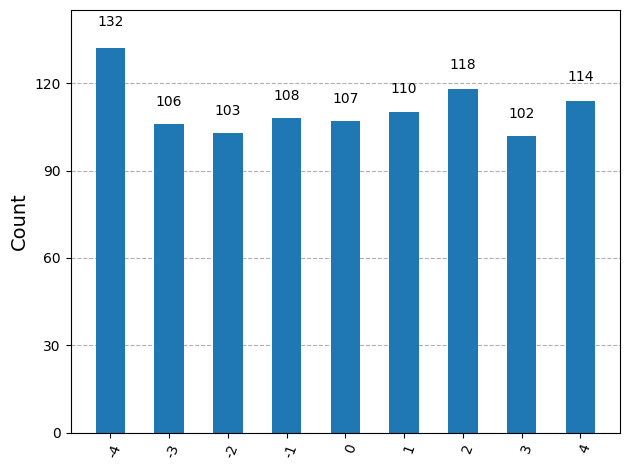

In [ ]:
from qiskit.visualization import plot_histogram

# Generate 1000 random integers in the range [-4, 4] and plot the histogram
min, max = -4, 4
values = [quantum_randint(min, max) for _ in range(1000)]

# Count occurrences of each value for histogram plotting (list to dict)
counts = {}
for v in values:
    counts[v] = counts.get(v, 0) + 1

# Plot the histogram
plot_histogram(counts)


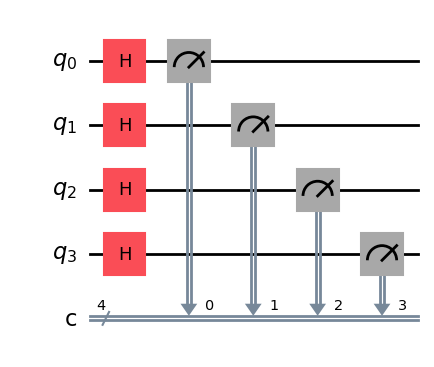

In [ ]:
# draw the circuit by using matplotlib
qc.draw(output='mpl') 

# quantum_randint(0, 15)


### Real application: calculate value of $\pi$ using random numbers (Montecarlo simulation)
- Consider a circle of radius R inside a square of side 2*R:
    - Area of the square = (2*R)^2
    - Area of the circle = $\pi$ * R^2
    - Areas ratio = 4 / $\pi$   -->   $\pi$ = 4 * Areas ratio 
- Generate random numbers, check if inside the circle:
    - Generate random numbers between [-R, R], this is, inside the square -> total_hits
    - Check and count number of hits inside the circle -> inside_hits
    - Ratio of total_hits vs. inside_hits should be same as the ratio between areas
    - Estimation of $\pi$ =  4 * (inside_hits / total_hits)

In [307]:
# Initialize parameters for Montecarlo simulation
radius = 100
total_hits = 10*radius
inside_hits = 0

# Perform Montecarlo simulation using quantum random numbers to estimate value of pi 
# For each hit, generate random (x, y) coordinates and check if they fall inside the circle
for _ in range(total_hits):
    x = quantum_randint(-radius, radius)
    y = quantum_randint(-radius, radius)
    if x**2 + y**2 <= radius**2:
        inside_hits += 1

# Estimate the value of pi as four times the ratio of hits inside the circle to total hits
number_pi = 4 * (inside_hits / total_hits)
print(f"Estimated value of pi: {number_pi}")


Estimated value of pi: 3.08


Run with higher radius to achieve better accuracy.